# ChurnShield — Model Training & Evaluation

**Objective:** Train, compare and select the best ML model for churn prediction.  
**Input:** `data/processed/telco_features.csv`  
**Output:** `models/best_model.pkl`

## Strategy :
- Baseline : Logistic Regression
- Challenger 1 : Random Forest
- Challenger 2 : XGBoost
- Tracking : MLflow
- Selection metric : F1-Score (handles class imbalance)

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load ML-ready dataset
df = pd.read_csv('../data/processed/telco_features.csv')

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Data split done")
print(f"   Train set : {X_train.shape} — Churn rate: {y_train.mean():.2%}")
print(f"   Test set  : {X_test.shape} — Churn rate: {y_test.mean():.2%}")

✅ Data split done
   Train set : (5625, 27) — Churn rate: 26.58%
   Test set  : (1407, 27) — Churn rate: 26.58%


In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model and return key metrics.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1     = f1_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred,
                                   target_names=['No Churn', 'Churn'])

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"\n{report}")

    return {'model': model_name, 'f1': f1, 'roc_auc': roc,
            'y_pred': y_pred, 'y_prob': y_prob}

In [4]:
# Create models directory
import os
os.makedirs('../models', exist_ok=True)

# Set MLflow experiment
mlflow.set_experiment("churnshield")

# Define models to train
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        scale_pos_weight=3,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

# Train, evaluate and track each model
results = []

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):

        # Train
        model.fit(X_train, y_train)

        # Evaluate
        metrics = evaluate_model(model, X_test, y_test, model_name)
        results.append(metrics)

        # Log to MLflow
        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("f1_score", metrics['f1'])
        mlflow.log_metric("roc_auc", metrics['roc_auc'])

        # Save model
        if "XGBoost" in model_name:
            mlflow.xgboost.log_model(model, model_name)
        else:
            mlflow.sklearn.log_model(model, model_name)

print("\n✅ All models trained and tracked in MLflow")

2026/05/06 02:16:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 02:16:28 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 02:16:31 INFO mlflow.tracking.fluent: Experiment with name 'churnshield' does not exist. Creating a new experiment.
2026/05/06 02:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  Logistic Regression
  F1-Score  : 0.6063
  ROC-AUC   : 0.8372

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.77      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



2026/05/06 02:16:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 02:17:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  Random Forest
  F1-Score  : 0.5309
  ROC-AUC   : 0.8129

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1033
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



2026/05/06 02:17:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/06 02:17:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost
  F1-Score  : 0.5902
  ROC-AUC   : 0.8107

              precision    recall  f1-score   support

    No Churn       0.87      0.76      0.81      1033
       Churn       0.51      0.70      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407


✅ All models trained and tracked in MLflow


In [5]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best parameters : {grid_search.best_params_}")
print(f"   Best CV F1-Score : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best parameters : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
   Best CV F1-Score : 0.6350


In [6]:
with mlflow.start_run(run_name="XGBoost_Tuned"):

    # Train with best parameters
    xgb_tuned = XGBClassifier(
        **grid_search.best_params_,
        scale_pos_weight=3,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    xgb_tuned.fit(X_train, y_train)

    # Evaluate
    metrics_tuned = evaluate_model(xgb_tuned, X_test, y_test, "XGBoost Tuned")
    results.append(metrics_tuned)

    # Log to MLflow
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("f1_score", metrics_tuned['f1'])
    mlflow.log_metric("roc_auc", metrics_tuned['roc_auc'])
    mlflow.xgboost.log_model(xgb_tuned, "XGBoost_Tuned")

print("\n✅ XGBoost Tuned tracked in MLflow")

2026/05/06 02:22:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Tuned
  F1-Score  : 0.6237
  ROC-AUC   : 0.8332

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


✅ XGBoost Tuned tracked in MLflow


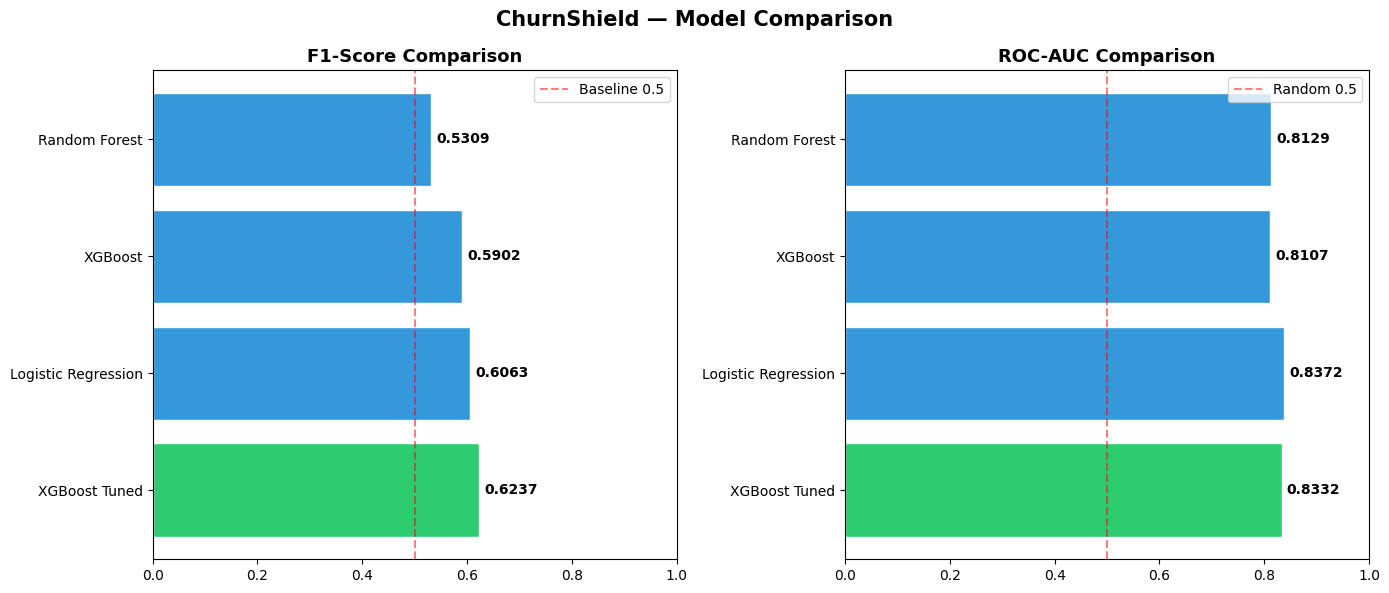

✅ Comparison plot saved


In [7]:
# Build results dataframe
results_df = pd.DataFrame([
    {'Model': r['model'], 'F1-Score': r['f1'], 'ROC-AUC': r['roc_auc']}
    for r in results
]).sort_values('F1-Score', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]

# F1-Score
bars = axes[0].barh(results_df['Model'], results_df['F1-Score'],
                     color=colors, edgecolor='white')
axes[0].set_title('F1-Score Comparison', fontweight='bold', fontsize=13)
axes[0].set_xlim(0, 1)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline 0.5')
for bar, val in zip(bars, results_df['F1-Score']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')
axes[0].legend()

# ROC-AUC
bars2 = axes[1].barh(results_df['Model'], results_df['ROC-AUC'],
                      color=colors, edgecolor='white')
axes[1].set_title('ROC-AUC Comparison', fontweight='bold', fontsize=13)
axes[1].set_xlim(0, 1)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random 0.5')
for bar, val in zip(bars2, results_df['ROC-AUC']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')
axes[1].legend()

plt.suptitle('ChurnShield — Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved")

In [8]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Best model = XGBoost Tuned
best_model = xgb_tuned

# Save model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature names for API
feature_names = list(X_train.columns)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("✅ Best model saved → models/best_model.pkl")
print(f"   Features : {len(feature_names)} columns")

✅ Best model saved → models/best_model.pkl
   Features : 27 columns


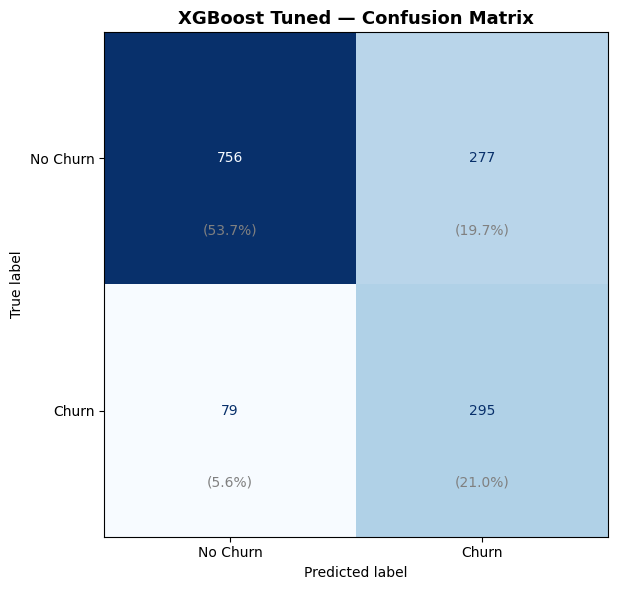

✅ Confusion matrix saved


In [9]:
# Confusion matrix for best model
y_pred_best = xgb_tuned.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('XGBoost Tuned — Confusion Matrix', 
             fontweight='bold', fontsize=13)

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.3, f'({pct:.1f}%)',
                ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

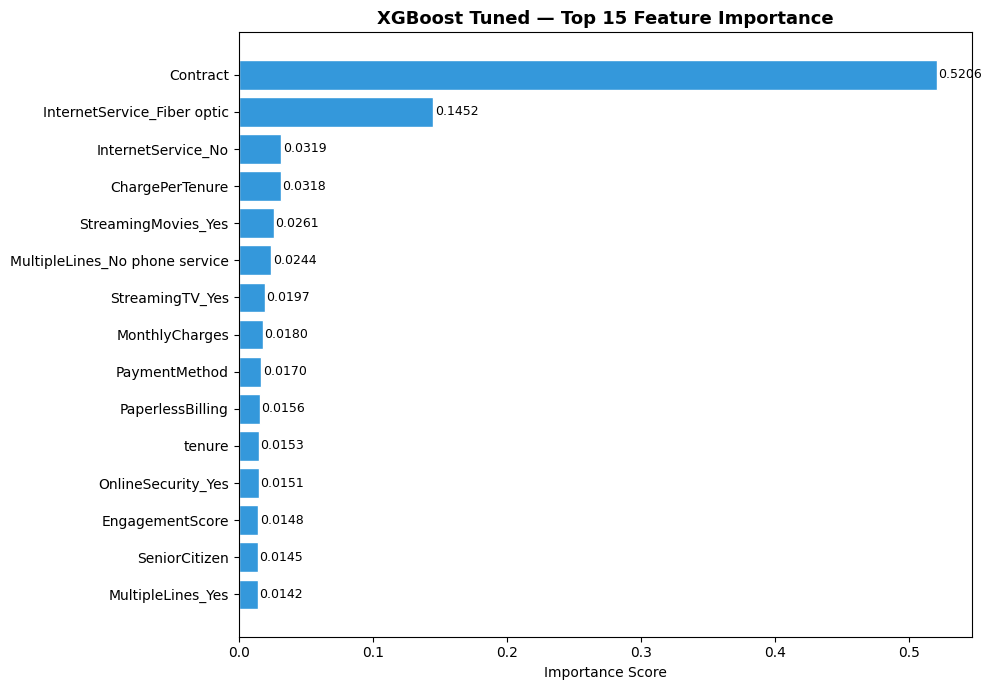

✅ Feature importance saved


In [10]:
# Feature importance from XGBoost
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#3498db', edgecolor='white')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('XGBoost Tuned — Top 15 Feature Importance',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved")

## Conclusions

**Best model : XGBoost Tuned**
- F1-Score : 0.6237
- ROC-AUC  : 0.8332
- Best parameters : learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.8

**Key takeaways :**
- Hyperparameter tuning improved XGBoost F1 from 0.59 → 0.62 (+3 points)
- Logistic Regression is a strong baseline — simple models should never be underestimated
- Random Forest underperformed due to low Recall on the minority class
- All experiments tracked in MLflow for full reproducibility

**Next step : FastAPI deployment**